# Empirical Check of Assumption 4: Reparameterizable Gradient Fidelity

This notebook empirically verifies whether the student model (LCM-SDXL) and the teacher
model (SDXL-Base) produce similar Jacobians with respect to the conditioning input $x$
(the text/prompt embedding).
- **$f_\star(x,\eta)$** — Teacher: SDXL-Base, $k$ DDIM steps  
- **$f_\phi(x,\eta)$** — Student: LCM-SDXL, 1 LCM step  
- **$\varepsilon_s = \|f_\star(x) - f_\phi(x)\|$** — Output gap  
- **$\varepsilon_g \approx \mathbb{E}_v\|\partial_x(v^\top f_\star) - \partial_x(v^\top f_\phi)\|$** — Jacobian gap (via random VJPs)

**Sections**
1. Imports & configuration  
2. Load models  
3. Sample images — visual comparison  
4. Gradient sanity check  
5. LCD-ODE coupled $\varepsilon_s$ / $\varepsilon_g$ experiment  
6. Results: summary table + plots  


## §1 — Imports & configuration

In [1]:
# ── dependencies ─────────────────────────────────────────────────────────────
# If running fresh:  !pip install diffusers transformers accelerate -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from diffusers import (
    StableDiffusionXLPipeline,
    UNet2DConditionModel,
    LCMScheduler,
    DDIMScheduler,

)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
# ── device ───────────────────────────────────────────────────────────────────
SEED   = 42
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if torch.cuda.is_available() else torch.float32\

print(f"Device: {device}  |  dtype: {dtype}")


Device: cuda  |  dtype: torch.float16


In [3]:
# ── experiment hyper-parameters ───────────────────────────────────────────────
HEIGHT, WIDTH = 512, 512        # image size (latent: H/8 × W/8 = 64×64)

# image sampling (§3)
N_TEACHER_SAMPLE_STEPS = 20     # DDIM steps for teacher images
N_STUDENT_SAMPLE_STEPS = 4      # LCM  steps for student images

# §5 experiment
K_SKIP     = 4                  # teacher ODE segment length  (k in the paper) ## REMOVE
N_RANDOM_V = 10                 # random VJP directions per (prompt, t_n)
GUIDANCE_W_TEACHER = 7.5
GUIDANCE_W_STUDENT = 1.0

PROMPTS = [
    "a golden retriever playing in a sunny park",
    "a red sports car on a mountain road",
    "a bowl of colorful fruit on a wooden table",
    "a snowy mountain peak at sunset",
    "an astronaut floating in outer space",
]


## §2 — Load models

Teacher and student share the **VAE and text encoders** — only the UNet differs.  
We hot-swap the UNet to build the student pipeline.


In [4]:
TEACHER_ID = "stabilityai/stable-diffusion-xl-base-1.0"
STUDENT_ID = "latent-consistency/lcm-sdxl"

print("Loading teacher pipeline (SDXL-Base + DDIM scheduler)...")
teacher_pipe = StableDiffusionXLPipeline.from_pretrained(
    TEACHER_ID,
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None,
    use_safetensors=True,
).to(device)
teacher_pipe.scheduler = DDIMScheduler.from_config(teacher_pipe.scheduler.config)
teacher_pipe.set_progress_bar_config(disable=True)
print("  ✓ Teacher ready.")


Loading teacher pipeline (SDXL-Base + DDIM scheduler)...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  ✓ Teacher ready.


In [5]:
from diffusers import LCMScheduler

print("Loading student UNet (LCM-SDXL)...")
student_unet = UNet2DConditionModel.from_pretrained(
    STUDENT_ID,
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None,
).to(device)

# 1. Start with the teacher's scheduler config
lcm_config = dict(teacher_pipe.scheduler.config)

# 2. Build the student pipeline
student_pipe = StableDiffusionXLPipeline(
    vae               = teacher_pipe.vae,
    text_encoder      = teacher_pipe.text_encoder,
    text_encoder_2    = teacher_pipe.text_encoder_2,
    tokenizer         = teacher_pipe.tokenizer,
    tokenizer_2       = teacher_pipe.tokenizer_2,
    unet              = student_unet,
    scheduler         = LCMScheduler.from_config(lcm_config),
).to(device)

student_pipe.set_progress_bar_config(disable=True)
print("  ✓ Student ready.")

Loading student UNet (LCM-SDXL)...


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/5.14G [00:00<?, ?B/s]

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  ✓ Student ready.


## §3 — Sample images & visual comparison

We use the **same seed** for both models so any visual difference is purely  
due to the model, not the initial noise $\eta$.


In [6]:
teacher_images, student_images = [], []

print("Sampling images...")
for i, prompt in enumerate(PROMPTS):

    gen = torch.Generator(device=device).manual_seed(SEED + i)
    with torch.no_grad():
        t_img = teacher_pipe(
            prompt, num_inference_steps=N_TEACHER_SAMPLE_STEPS,
            guidance_scale=7.5, generator=gen, height=HEIGHT, width=WIDTH,
        ).images[0]

    gen = torch.Generator(device=device).manual_seed(SEED + i)   # reset same seed
    with torch.no_grad():
        s_img = student_pipe(
            prompt, num_inference_steps=N_STUDENT_SAMPLE_STEPS,
            # guidance_scale=8.5,
            generator=gen, height=HEIGHT, width=WIDTH,
        ).images[0]

    teacher_images.append(t_img)
    student_images.append(s_img)
    print(f"  [{i+1}/{len(PROMPTS)}] {prompt[:50]}")


Sampling images...
  [1/5] a golden retriever playing in a sunny park
  [2/5] a red sports car on a mountain road
  [3/5] a bowl of colorful fruit on a wooden table
  [4/5] a snowy mountain peak at sunset
  [5/5] an astronaut floating in outer space


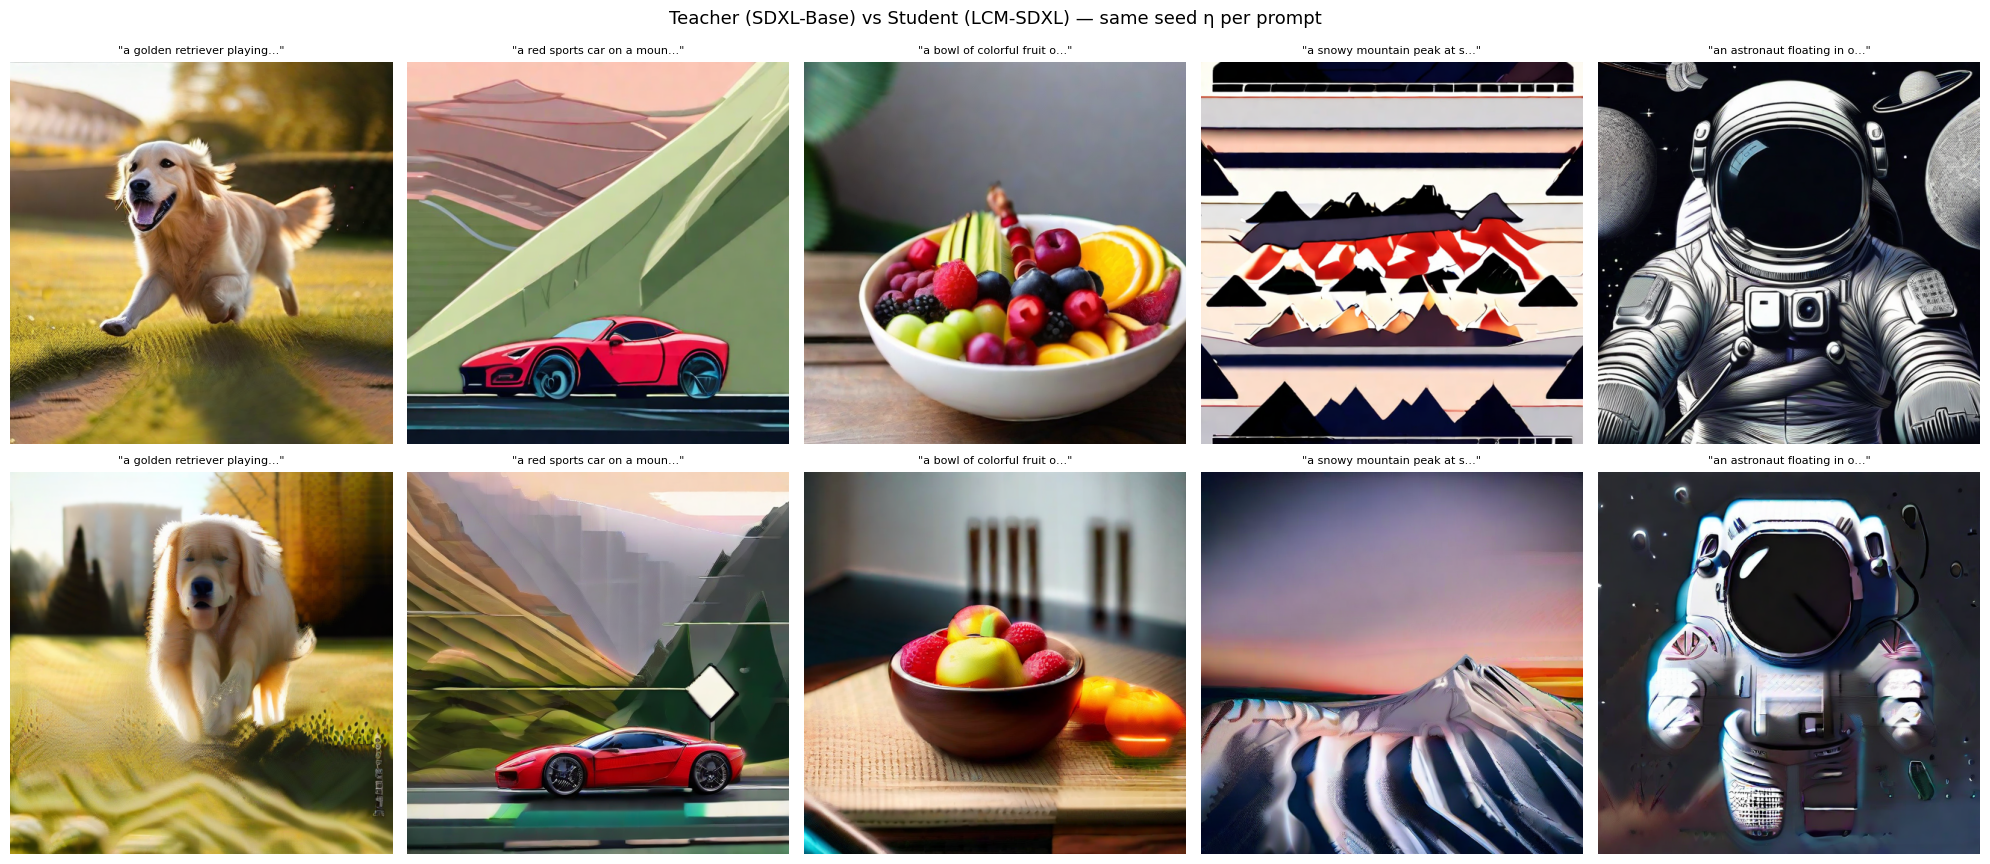

In [7]:
fig, axes = plt.subplots(2, len(PROMPTS), figsize=(4 * len(PROMPTS), 9))

for i, prompt in enumerate(PROMPTS):
    for row, (img, label) in enumerate([
        (teacher_images[i], f"Teacher\n({N_TEACHER_SAMPLE_STEPS} DDIM steps)"),
        (student_images[i], f"Student LCM\n({N_STUDENT_SAMPLE_STEPS} steps)"),
    ]):
        axes[row, i].imshow(img)
        axes[row, i].set_title(f'"{prompt[:26]}…"', fontsize=8)
        axes[row, i].axis("off")

axes[0, 0].set_ylabel("Teacher", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Student (LCM)", fontsize=11, fontweight="bold")
plt.suptitle(
    "Teacher (SDXL-Base) vs Student (LCM-SDXL) — same seed η per prompt",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("fig1_samples.png", dpi=120, bbox_inches="tight")
plt.show()


## §4 — Gradient sanity check

We verify that `torch.autograd` can differentiate through a single UNet forward pass  
with respect to the text embedding $x$.  
If this fails, MLGD-D guidance would also fail.


In [8]:
# AFTER
def encode_prompt(pipe, prompt):
    with torch.no_grad():
        pe, _, pooled, _ = pipe.encode_prompt(
            prompt=prompt, device=device,
            num_images_per_prompt=1, do_classifier_free_guidance=False,
        )
        ne, _, n_pooled, _ = pipe.encode_prompt(
            prompt="", device=device,
            num_images_per_prompt=1, do_classifier_free_guidance=False,
        )
    return pe.to(dtype), pooled.to(dtype), ne.to(dtype), n_pooled.to(dtype)


def unet_forward(unet, latent, prompt_embeds, pooled_embeds, timestep):
    """Single UNet denoising step.  Returns the predicted noise tensor."""
    added_cond = {
        "text_embeds": pooled_embeds,
        "time_ids": torch.tensor(
            [[HEIGHT, WIDTH, 0, 0, HEIGHT, WIDTH]], dtype=dtype, device=device
        ),
    }
    return unet(
        latent, timestep,
        encoder_hidden_states=prompt_embeds,
        added_cond_kwargs=added_cond,
    ).sample


In [9]:
pe0, pooled0, ne0, n_pooled0 = encode_prompt(teacher_pipe, PROMPTS[0])

torch.manual_seed(SEED)
eta0 = torch.randn(1, 4, HEIGHT // 8, WIDTH // 8, dtype=dtype, device=device)
t500 = torch.tensor([500], device=device)

print("§4 Gradient sanity check")
print("-" * 55)
for name, unet in [("Teacher", teacher_pipe.unet), ("Student", student_unet)]:
    unet.train()                            # required for gradient computation
    x = pe0.detach().requires_grad_(True)
    out = unet_forward(unet, eta0, x, pooled0, t500)
    out.sum().backward()

    g = x.grad
    print(f"  {name:8s} | shape {list(g.shape)} | "
          f"NaN: {torch.isnan(g).any().item()} | "
          f"norm: {g.norm().item():.5f}")

print("\n  ✓ Both UNets are differentiable w.r.t. prompt embeddings.")


§4 Gradient sanity check
-------------------------------------------------------
  Teacher  | shape [1, 77, 2048] | NaN: False | norm: 25.04688
  Student  | shape [1, 77, 2048] | NaN: False | norm: 26.73438

  ✓ Both UNets are differentiable w.r.t. prompt embeddings.


## §5 — LCD-ODE coupled $\varepsilon_s$ / $\varepsilon_g$ experiment

We compare the **full denoising**

- **Teacher** $f_\star(x)$: $K$ DDIM steps, $z_{t_{nk}} \to z_{0}$
- **Student** $f_\phi(x)$: steps defined above LCM step - $z_{t_{nk}} \to z_{0}$

For a fixed $(x, \eta, t_n)$:

$$\varepsilon_s = \|f_\star(x) - f_\phi(x)\| \quad\text{(output gap)}$$

$$\varepsilon_g \approx \frac{1}{K}\sum_k \|\partial_x(v_k^\top f_\star) - \partial_x(v_k^\top f_\phi)\| \quad\text{(Jacobian gap via random VJPs)}$$

**Interpretation**
- $\varepsilon_g \approx \varepsilon_s$: Assumption 4 supported in the original sense  
- $\varepsilon_g \ll \varepsilon_s$: gradients agree far better than outputs — *strong* support for using $f_\phi$ as a drop-in guidance surrogate


### Helper functions

In [10]:
def noise_latent(z0, t_val, noise, scheduler):
    """
    Forward diffusion: z_{t_val} = sqrt(ᾱ_t)·z0 + sqrt(1−ᾱ_t)·noise.
    Mimics the noise level at timestep t_val using the scheduler's alpha schedule.
    """
    alpha = scheduler.alphas_cumprod[t_val].to(z0.device, z0.dtype)
    return (alpha ** 0.5) * z0 + ((1 - alpha) ** 0.5) * noise



def teacher_full(scheduler, z_nk, t_nk_idx, prompt_embeds, pooled_embeds, null_embeds, null_pooled):
    """
    Run all remaining DDIM steps from z_nk to z_0.

    Args
    ----
    scheduler     : DDIM scheduler with pre-set timesteps
    z_nk          : starting latent  [1, 4, H/8, W/8]
    t_nk_idx      : scheduler index corresponding to t_nk
    prompt_embeds : text conditioning  x  [1, L, D]
    pooled_embeds : pooled text conditioning  [1, D']
    null_embeds   : null (empty prompt) text conditioning  [1, L, D]
    null_pooled   : null (empty prompt) pooled conditioning  [1, D']

    Returns
    -------
    Latent after full denoising to z_0  [1, 4, H/8, W/8]
    """
    added_cond = {
        "text_embeds": pooled_embeds,
        "time_ids": torch.tensor(
            [[HEIGHT, WIDTH, 0, 0, HEIGHT, WIDTH]], dtype=dtype, device=device
        ),
    }
    null_cond = {
        "text_embeds": null_pooled,
        "time_ids": torch.tensor(
            [[HEIGHT, WIDTH, 0, 0, HEIGHT, WIDTH]], dtype=dtype, device=device
        ),
    }

    latent = z_nk
    for t in scheduler.timesteps[t_nk_idx:]:
        noise_pred = teacher_pipe.unet(
            latent, t,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs=added_cond,
        ).sample

        if GUIDANCE_W_TEACHER > 0:
            noise_uncond = teacher_pipe.unet(
                latent, t,
                encoder_hidden_states=null_embeds,
                added_cond_kwargs=null_cond,
            ).sample
            noise_pred = (1 + GUIDANCE_W_TEACHER) * noise_pred - GUIDANCE_W_TEACHER * noise_uncond

        latent = scheduler.step(noise_pred, t, latent).prev_sample
    return latent

def student_n_steps(scheduler, z_nk, t_nk_idx, prompt_embeds, pooled_embeds, n_steps=N_STUDENT_SAMPLE_STEPS):
    """
    Exact equivalent of student_pipe(..., guidance_scale=0.0)
    No CFG — this is how LCM-SDXL was trained and should be run.
    """
    added_cond = {
        "text_embeds": pooled_embeds,
        "time_ids": torch.tensor(
            [[HEIGHT, WIDTH, 0, 0, HEIGHT, WIDTH]], dtype=dtype, device=device
        ),
    }

    # 1. Scale initial noise (pipe calls prepare_latents which does this)
    latents = z_T * scheduler.init_noise_sigma  # usually 1.0 for LCM, but be explicit

    for t in scheduler.timesteps:
        # 2. scale_model_input — no-op for LCM but pipe always calls it
        latent_input = scheduler.scale_model_input(latents, t)

        noise_pred = student_unet(
            latent_input, t,
            encoder_hidden_states=prompt_embeds,
            added_cond_kwargs=added_cond,
        ).sample

        # 3. No CFG — single forward pass, no uncond
        latents = scheduler.step(noise_pred, t, latents).prev_sample

    return latents

def compute_vjp(fn, x_embed, v):
    """
    Compute the vector-Jacobian product  ∂_x (v^T fn(x))  via one backward pass.

    Instead of materialising the full (expensive) Jacobian ∂_x f ∈ R^{out × in},
    we project onto a random unit vector v and differentiate the scalar v^T f(x).
    Averaging ‖∂_x(v^T f_★) − ∂_x(v^T f_φ)‖ over many v's gives a Frobenius-norm
    estimate of ‖∂_x f_★ − ∂_x f_φ‖.

    Args
    ----
    fn      : callable x → tensor, differentiable in x
    x_embed : prompt embeddings [1, L, D]
    v       : random unit vector in output space, same shape as fn(x)

    Returns
    -------
    Gradient w.r.t. x_embed, same shape as x_embed
    """
    x = x_embed.detach().requires_grad_(True)
    out = fn(x)
    (out * v).sum().backward()
    return x.grad.detach().clone()


### Main experiment loop

In [11]:
PROMPTS = [
    "a golden retriever playing in a sunny park",
    "a red sports car on a mountain road",
    "a bowl of colorful fruit on a wooden table",
    "a snowy mountain peak at sunset",
    "an astronaut floating in outer space",
    "a cat sitting on a windowsill in the rain",
    "a bustling Tokyo street at night",
    "a lone lighthouse on a rocky coast",
    "a field of lavender under a purple sky",
    "a steaming cup of coffee on a wooden desk",
    "a polar bear walking on Arctic ice",
    "a vintage train passing through autumn forest",
    "a crowded beach on a summer day",
    "a medieval castle on a hilltop at dusk",
    "a hummingbird hovering near a red flower",
    "a neon-lit cyberpunk alley in the rain",
    "a waterfall in a tropical rainforest",
    "a child flying a kite in an open meadow",
    "a wolf howling at the full moon",
    "a glass of water with ice and lemon",
    "a row of colorful houses in a Scandinavian village",
    "a dragon perched on a mountain peak",
    "a farmer working in a rice paddy at sunrise",
    "a spaceship landing on a red desert planet",
    "a cozy fireplace in a snowy cabin interior",
    "a grand piano in an empty concert hall",
    "a market stall overflowing with spices",
    "a surfer riding a massive ocean wave",
    "a hot air balloon over a desert canyon",
    "a fox in a snowy pine forest",
    "a futuristic city skyline at golden hour",
    "a close-up of a bee on a sunflower",
    "an old man reading a book in a library",
    "a fishing boat at sea during a storm",
    "a tiger drinking from a jungle river",
    "a cobblestone street in a rainy European city",
    "a chef plating an elegant dish in a restaurant",
    "a glacier calving into a turquoise sea",
    "a young girl dancing in a flower field",
    "a robot walking through a futuristic museum",
    "a deer grazing in a misty morning forest",
    "a sailing yacht on a calm blue ocean",
    "a beekeeper tending hives in golden afternoon light",
    "a crowded subway platform in New York City",
    "a snowy owl perched on a branch at night",
    "a volcano erupting at night over the ocean",
    "a samurai standing in a bamboo forest",
    "a penguin colony on an Antarctic shore",
    "a street musician playing violin in the rain",
    "a sunflower field stretching to the horizon",

]

In [12]:
# PROMPTS = [
#     # Animals - specific breed, pose, environment, lighting
#     "a golden retriever with a red collar sitting facing left on green grass, midday sunlight casting short shadows, shallow depth of field",
#     "a white polar bear walking right on flat blue Arctic sea ice, overcast diffuse lighting, wide angle",
#     "a grey wolf with amber eyes standing on a snow-covered rock howling upward, full moon directly overhead, night scene",
#     "a Bengal tiger with orange and black stripes crouching at the edge of a brown river, dense green jungle behind, midday",
#     "a snowy owl with yellow eyes perched on a bare birch branch, dark blue night sky, front-facing portrait",
#     "a hummingbird with iridescent green plumage hovering to the right of a single red flower, white blurred background, close-up",
#     "a red fox sitting upright on white snow between two pine trees, soft winter light, eye-level perspective",
#     "a honey bee on the center of a yellow sunflower, macro lens, blurred green field background, bright afternoon light",
#     "a penguin colony of ten penguins standing on grey rock shore, grey cloudy sky, Antarctic landscape, wide shot",
#     "a white-tailed deer eating grass in a misty pine forest, early morning, soft diffused light, side profile",

#     # Vehicles and transport
#     "a red Ferrari 458 parked on a winding grey asphalt mountain road, rocky cliff on the left, clear blue sky, noon light",
#     "a black steam locomotive moving right through dense golden autumn forest, grey smoke from chimney, side view",
#     "a white sailing yacht on flat calm turquoise ocean, blue sky with scattered clouds, aerial view from above",
#     "a wooden fishing boat in rough grey ocean waves, dark storm clouds, rain streaks, low horizon",
#     "a silver spaceship with four landing legs descending vertically onto red Martian desert, dust cloud below, orange sky",

#     # People
#     "an Asian woman astronaut in white spacesuit floating in front of a large circular porthole showing Earth, interior of ISS, warm artificial lighting",
#     "an elderly white man with glasses reading a thick leather-bound book under a green desk lamp in a dark wood library, front view",
#     "a male chef in white uniform and tall hat plating a circular dish with tweezers on a white plate, stainless steel kitchen, overhead light",
#     "a young girl in a yellow dress running toward the camera in a field of white daisies, bright afternoon sun, slight motion blur",
#     "a Japanese samurai in black armor standing still in a dense green bamboo forest, diffused morning light, mid-shot",
#     "a street musician in a brown coat playing a violin in a wet cobblestone alley, blurred yellow lights behind, night scene",
#     "a male surfer in a black wetsuit riding the face of a large green-blue wave from left to right, white foam, afternoon",
#     "a female beekeeper in white suit and mesh hat holding a wooden frame with honeycomb, golden afternoon backlight, garden setting",
#     "a South Asian farmer in a wide straw hat bent over transplanting rice seedlings in a flooded paddy, orange sunrise sky",
#     "a small child in a red jacket flying a blue diamond kite in an open green meadow, few white clouds, late afternoon",

#     # Landscapes and nature
#     "a single snow-capped mountain peak reflected perfectly in a still alpine lake, clear blue sky, no clouds, wide angle",
#     "a narrow rectangular waterfall dropping thirty meters into a green pool in a tropical forest, wet rock walls either side, noon",
#     "a purple lavender field in rows converging to the center, clear violet-blue sky, late afternoon warm light, wide shot",
#     "a field of sunflowers all facing right, dense from edge to edge, flat horizon, bright midday sun",
#     "a grey lighthouse on brown jagged coastal rocks, white waves crashing below, overcast sky, wide angle",
#     "a black lava flow entering the ocean at night, orange glow, steam rising, dark sky, wide shot",
#     "a large iceberg calving vertically into turquoise water, white and blue tones, overcast sky, dramatic splash",
#     "a narrow canyon with red sandstone walls and a hot air balloon visible far above, bottom-up perspective, noon",
#     "a glacier with blue crevasses viewed from eye level, flat white sky, no people, wide angle",
#     "a green rice paddy field with flooded rows reflecting orange sunrise sky, flat landscape, wide shot",

#     # Urban and architecture
#     "a narrow rain-wet Tokyo street at night with red and white neon signs reflecting on black asphalt, few pedestrians with umbrellas, eye level",
#     "a narrow European cobblestone alley with yellow stone buildings either side, rain puddles, overcast grey sky, empty, wide angle",
#     "a row of six identical red wooden houses with white trim on a flat grey Norwegian village street, overcast sky, wide shot",
#     "a dense New York City subway platform with many people waiting, yellow signage, fluorescent lighting, platform edge visible",
#     "a grand concert hall with a black Steinway grand piano center stage under a single spotlight, empty red seats surrounding, wide angle",
#     "a medieval stone castle on top of a steep green hill, orange dusk sky, no people, wide shot",
#     "a futuristic city skyline with tall glass towers and flying vehicles, golden hour warm light, city reflection in water below",
#     "a narrow cyberpunk alley with purple and cyan neon signs on both walls, rain falling, wet reflective black ground, night",

#     # Objects and still life
#     "a white ceramic bowl filled with twelve pieces of bright mixed fruit on a dark walnut table, soft window light from the left, close-up",
#     "a white ceramic mug with black coffee on a rough wooden desk next to an open notebook, single warm desk lamp, top-down view",
#     "a clear glass filled with ice, lemon slices, and still water on a white marble surface, bright diffused natural light, close-up",
#     "a market stall with seven large wooden bowls filled with red, yellow, orange, and green spices, overhead warm light, tight shot",
#     "a lit red brick fireplace with three logs burning, snow visible through a small square window behind, cozy dark interior",
#     "a large stone dragon with folded grey wings perched on a snow-capped mountain peak, cloudy dark sky, dramatic low angle",
#     "a red cozy armchair beside a round side table with a book on it inside a wood cabin, warm amber interior lighting, wide angle",
# ]

# PHOTO_PREFIX = (
#     "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, "
#     "Canon EOS R5, RAW, sharp focus, "
# )
# PHOTO_SUFFIX = (
#     ", photorealistic, hyperrealistic, film grain, "
#     "no illustration, no cartoon, no painting, no CGI"
# )

# PROMPTS = [
#     PHOTO_PREFIX + p + PHOTO_SUFFIX
#     for p in PROMPTS
# ]

In [13]:
N_STUDENT_SAMPLE_STEPS=4

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


ε_s / ε_g experiment
  Teacher: 20 DDIM steps, z_T → z_0, guidance=7.5
  Student: 4 LCM  steps, z_T → z_0, guidance=1.0
  VJP directions: 10

[1/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a golden retriever with a red collar sitting facing left on green grass, midday sunlight casting short shadows, shallow depth of field, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


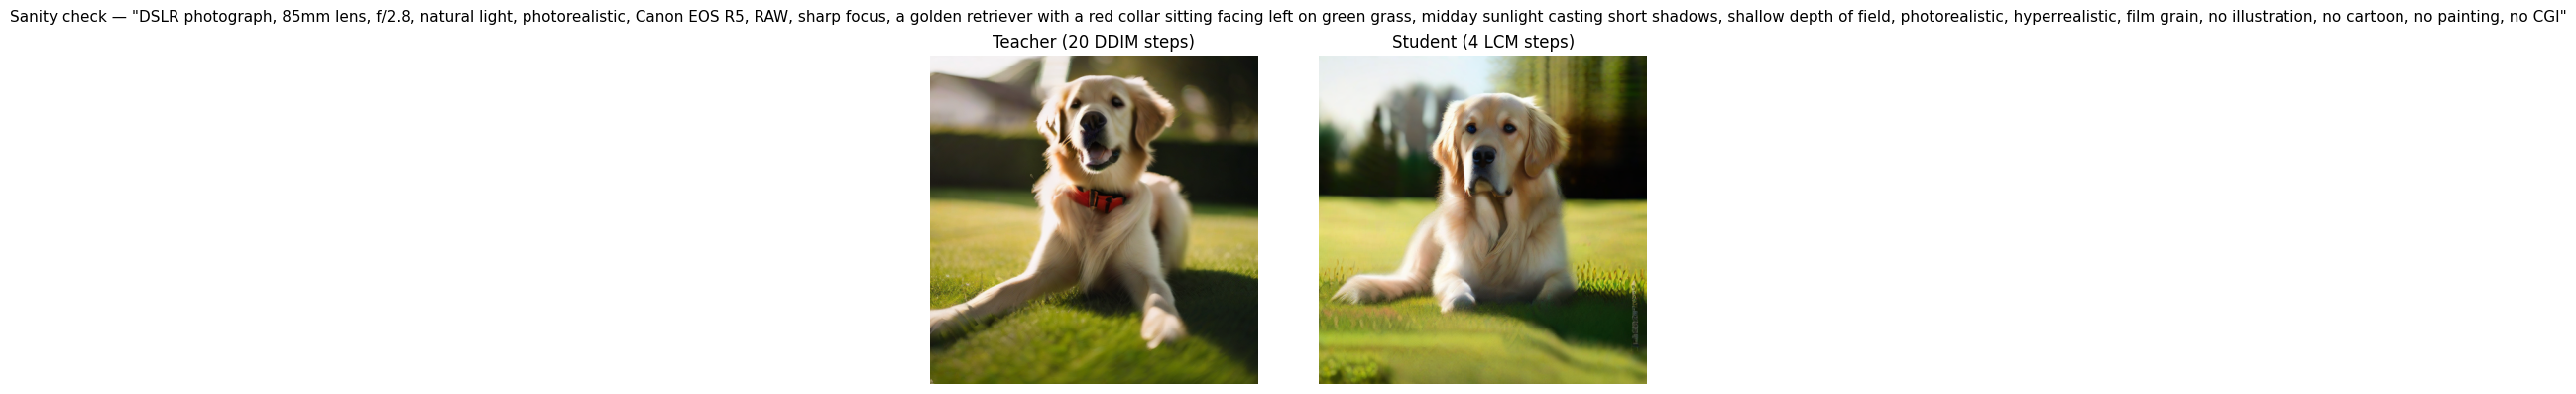

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [1]:
    v[00]: 16.4601
    v[01]: 30.3440
    v[02]: 85.7808
    v[03]: 31.6266
    v[04]: 16.2877
    v[05]: 9.0544
    v[06]: 4.9632
    v[07]: 6.9692
    v[08]: 21.4857
    v[09]: 38.3730
  ε_s=107.5560 | ε_g(mean)=26.1345 | ε_g(median)=18.9729 | ±22.5273 | ‖f_φ‖=113.9189 | ‖∂_x[vᵀf_φ]‖=0.4682

[2/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a white polar bear walking right on flat blue Arctic sea ice, overcast diffuse lighting, wide angle, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


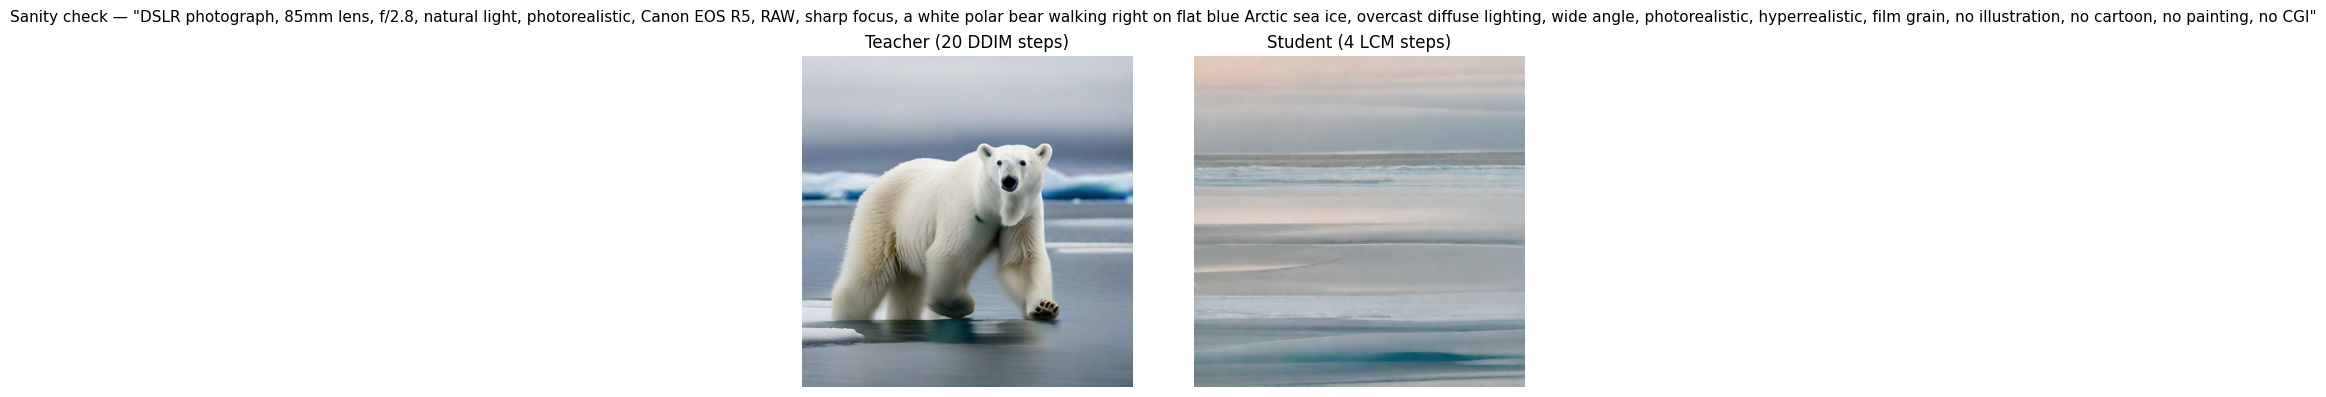

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [2]:
    v[00]: 26.8228
    v[01]: 39.2966
    v[02]: 20.5530
    v[03]: 9.9545
    v[04]: 81.4761
    v[05]: 13.0446
    v[06]: 17.4068
    v[07]: 123.5084
    v[08]: 30.3705
    v[09]: 57.5755
  ε_s=84.0231 | ε_g(mean)=42.0009 | ε_g(median)=28.5966 | ±34.2748 | ‖f_φ‖=73.5507 | ‖∂_x[vᵀf_φ]‖=0.3136

[3/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a grey wolf with amber eyes standing on a snow-covered rock howling upward, full moon directly overhead, night scene, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


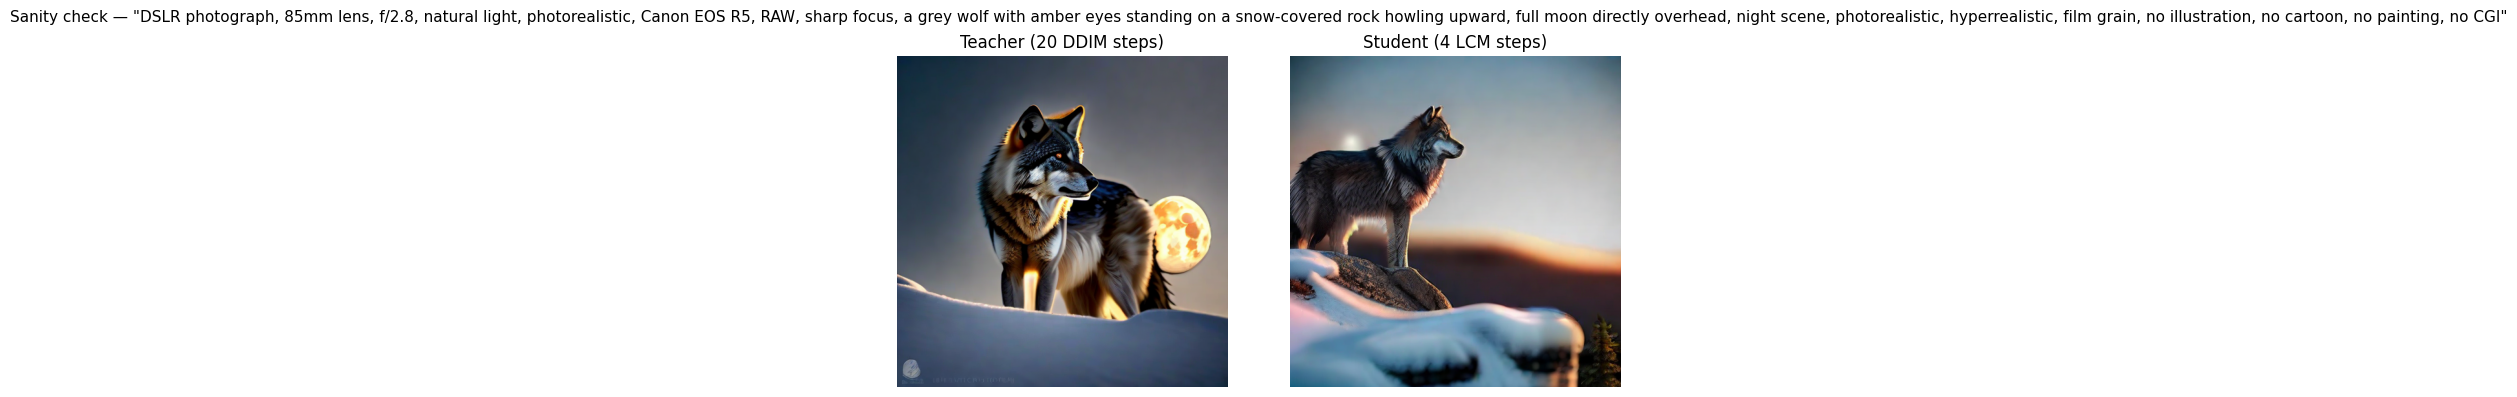

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [3]:
    v[00]: 160.6309
    v[01]: 127.2467
    v[02]: 92.7066
    v[03]: 17.6625
    v[04]: 262.8412
    v[05]: 48.0834
    v[06]: 256.2535
    v[07]: 358.5114
    v[08]: 68.0612
    v[09]: 311.2012
  ε_s=116.7553 | ε_g(mean)=170.3199 | ε_g(median)=143.9388 | ±113.0859 | ‖f_φ‖=98.6269 | ‖∂_x[vᵀf_φ]‖=0.3237

[4/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a Bengal tiger with orange and black stripes crouching at the edge of a brown river, dense green jungle behind, midday, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


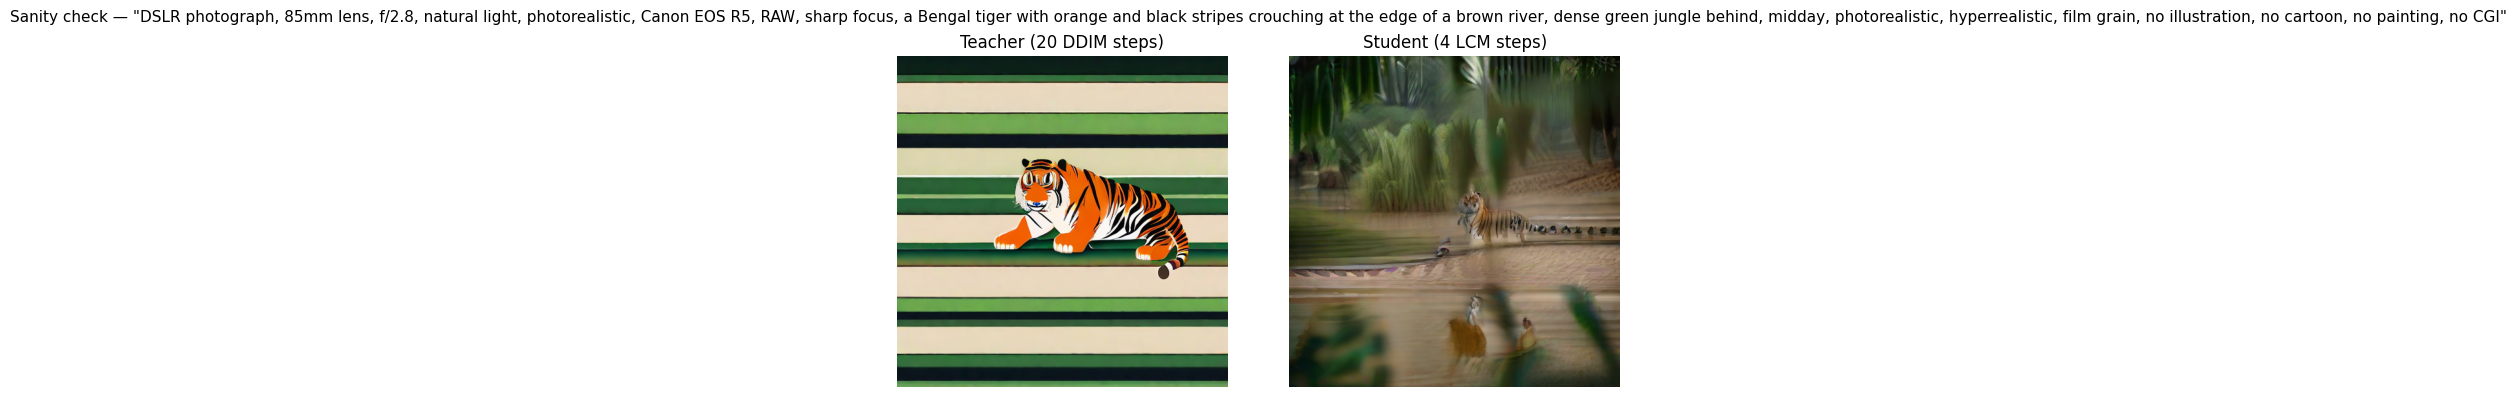

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [4]:
    v[00]: 774.3578
    v[01]: 196.6331
    v[02]: 587.2807
    v[03]: 305.1820
    v[04]: 306.0121
    v[05]: 268.1280
    v[06]: 671.4481
    v[07]: 394.3223
    v[08]: 83.7440
    v[09]: 227.8846
  ε_s=145.2039 | ε_g(mean)=381.4993 | ε_g(median)=305.5970 | ±212.5383 | ‖f_φ‖=97.3193 | ‖∂_x[vᵀf_φ]‖=0.3156

[5/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a snowy owl with yellow eyes perched on a bare birch branch, dark blue night sky, front-facing portrait, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


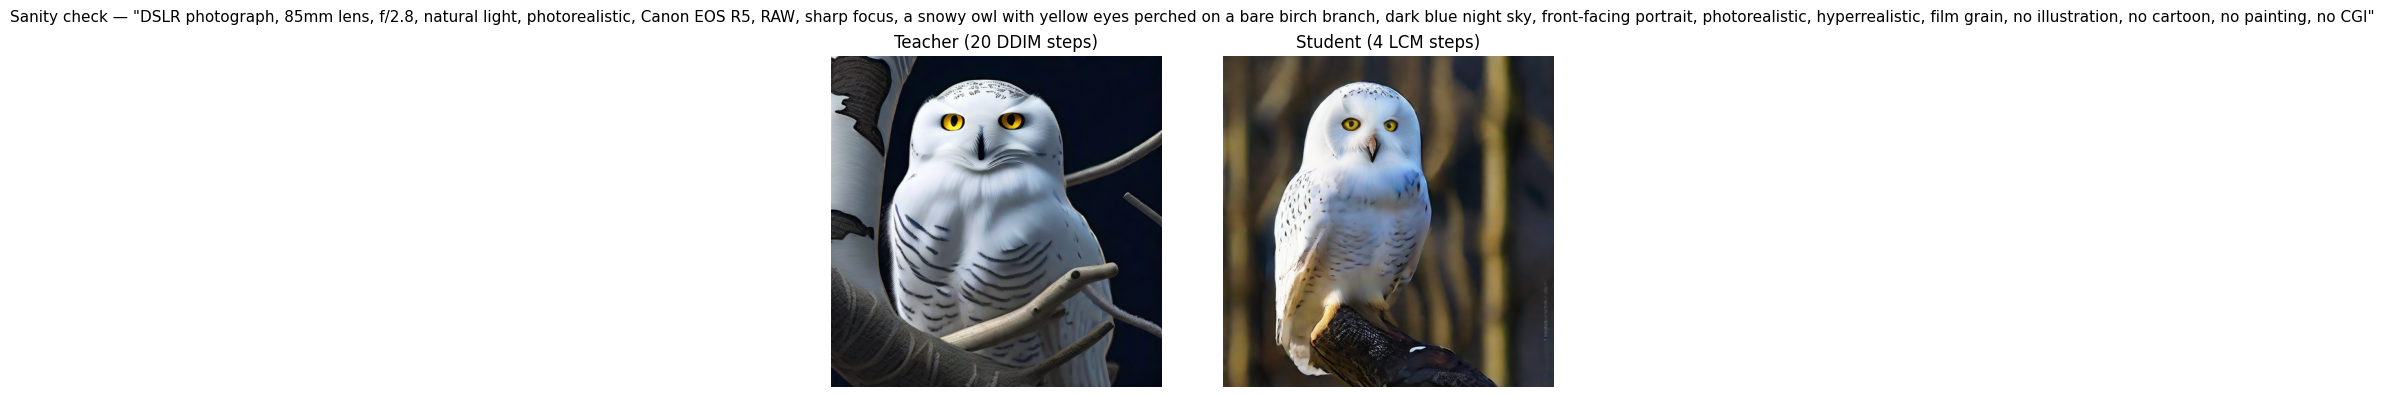

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['cgi']
Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['cgi']


  Individual ‖g_t - g_s‖ norms for prompt [5]:
    v[00]: 39798.9023
    v[01]: 1982.4124
    v[02]: 73646.6875
    v[03]: nan
    v[04]: nan
    v[05]: nan
    v[06]: nan
    v[07]: 85211.1484
    v[08]: 77050.9062
    v[09]: 558.3262
  ε_s=125.2761 | ε_g(mean)=nan | ε_g(median)=nan | ±nan | ‖f_φ‖=114.9333 | ‖∂_x[vᵀf_φ]‖=0.8017

[6/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a hummingbird with iridescent green plumage hovering to the right of a single red flower, white blurred background, close-up, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


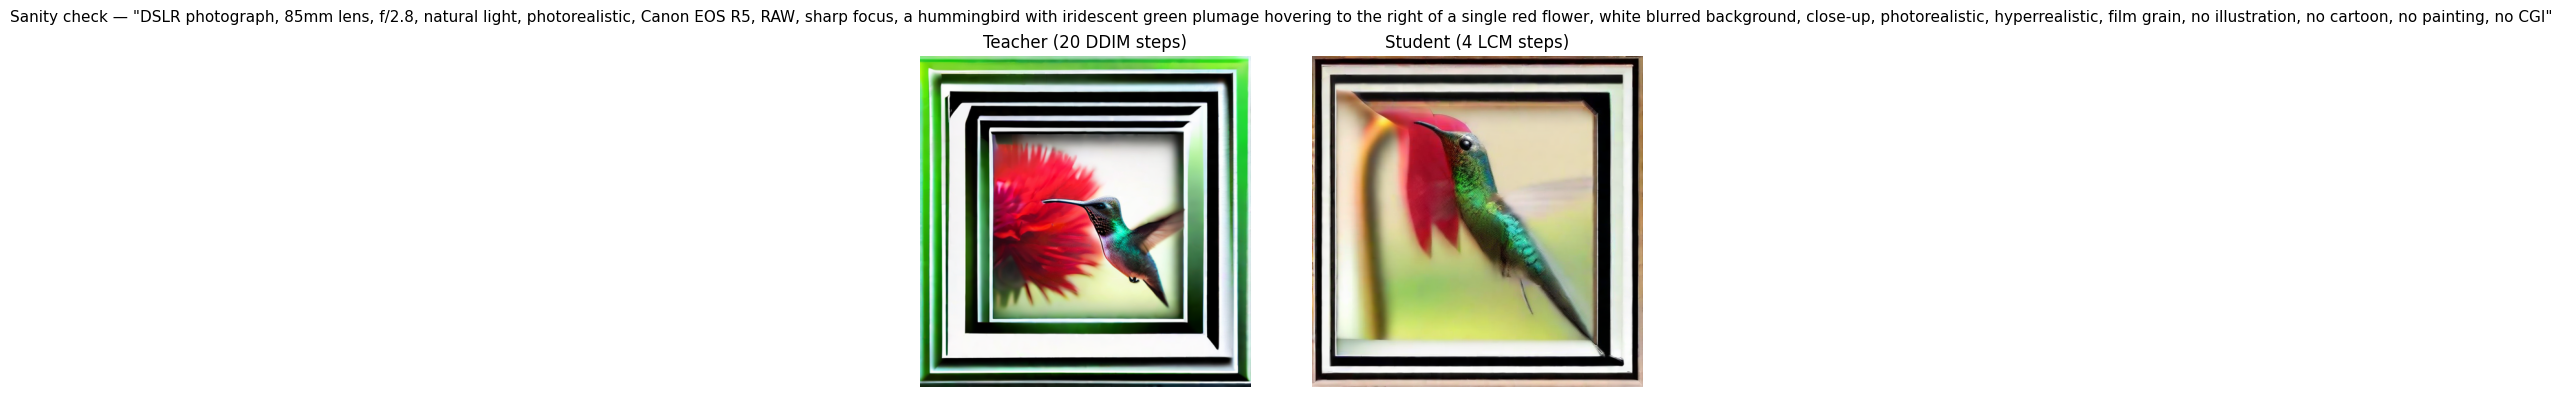

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [6]:
    v[00]: 16.6638
    v[01]: 28.3133
    v[02]: 16.5377
    v[03]: 24.1314
    v[04]: 29.0595
    v[05]: 20.7496
    v[06]: 13.8930
    v[07]: 28.5452
    v[08]: 11.9179
    v[09]: 25.8240
  ε_s=138.1884 | ε_g(mean)=21.5635 | ε_g(median)=22.4405 | ±6.1404 | ‖f_φ‖=126.3797 | ‖∂_x[vᵀf_φ]‖=0.3179

[7/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a red fox sitting upright on white snow between two pine trees, soft winter light, eye-level perspective, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


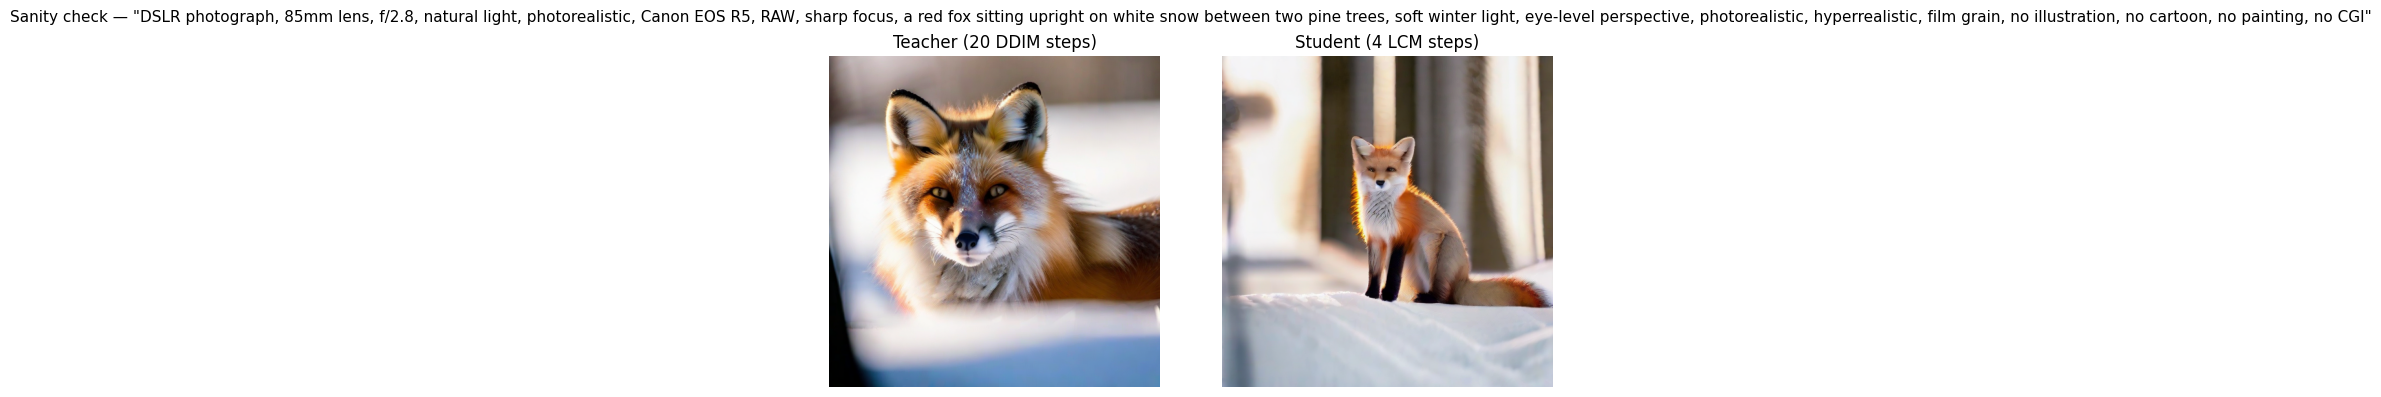

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [7]:
    v[00]: 20.3960
    v[01]: 38.4086
    v[02]: 25.1034
    v[03]: 20.1674
    v[04]: 21.7409
    v[05]: 37.7060
    v[06]: 4.4142
    v[07]: 13.5198
    v[08]: 43.2091
    v[09]: 3.9693
  ε_s=118.6374 | ε_g(mean)=22.8635 | ε_g(median)=21.0685 | ±12.9623 | ‖f_φ‖=99.3796 | ‖∂_x[vᵀf_φ]‖=0.3994

[8/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a honey bee on the center of a yellow sunflower, macro lens, blurred green field background, bright afternoon light, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


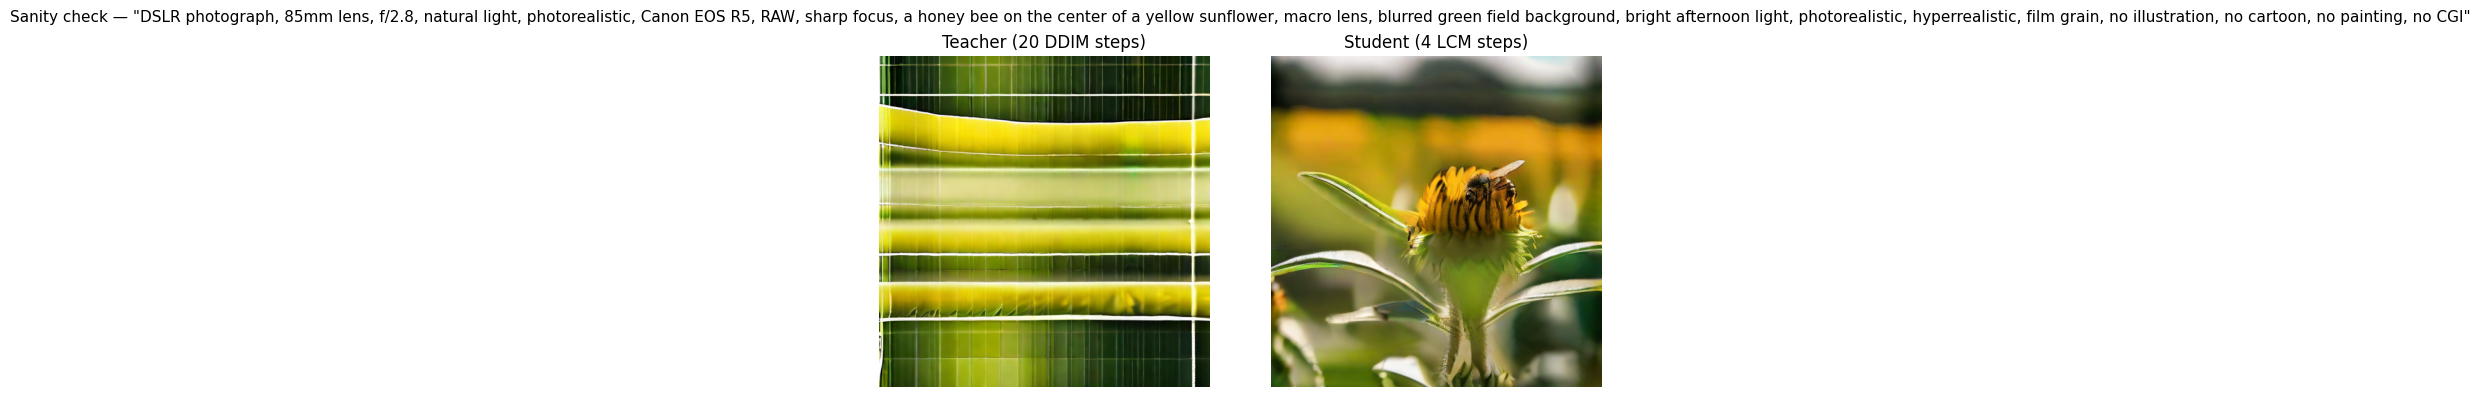

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [8]:
    v[00]: 89.1297
    v[01]: 98.4149
    v[02]: 153.2154
    v[03]: 67.8581
    v[04]: 346.2757
    v[05]: 265.2376
    v[06]: 185.7915
    v[07]: 51.8895
    v[08]: 85.6454
    v[09]: 71.0015
  ε_s=150.0834 | ε_g(mean)=141.4459 | ε_g(median)=93.7723 | ±92.4581 | ‖f_φ‖=127.4861 | ‖∂_x[vᵀf_φ]‖=0.2834

[9/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a penguin colony of ten penguins standing on grey rock shore, grey cloudy sky, Antarctic landscape, wide shot, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


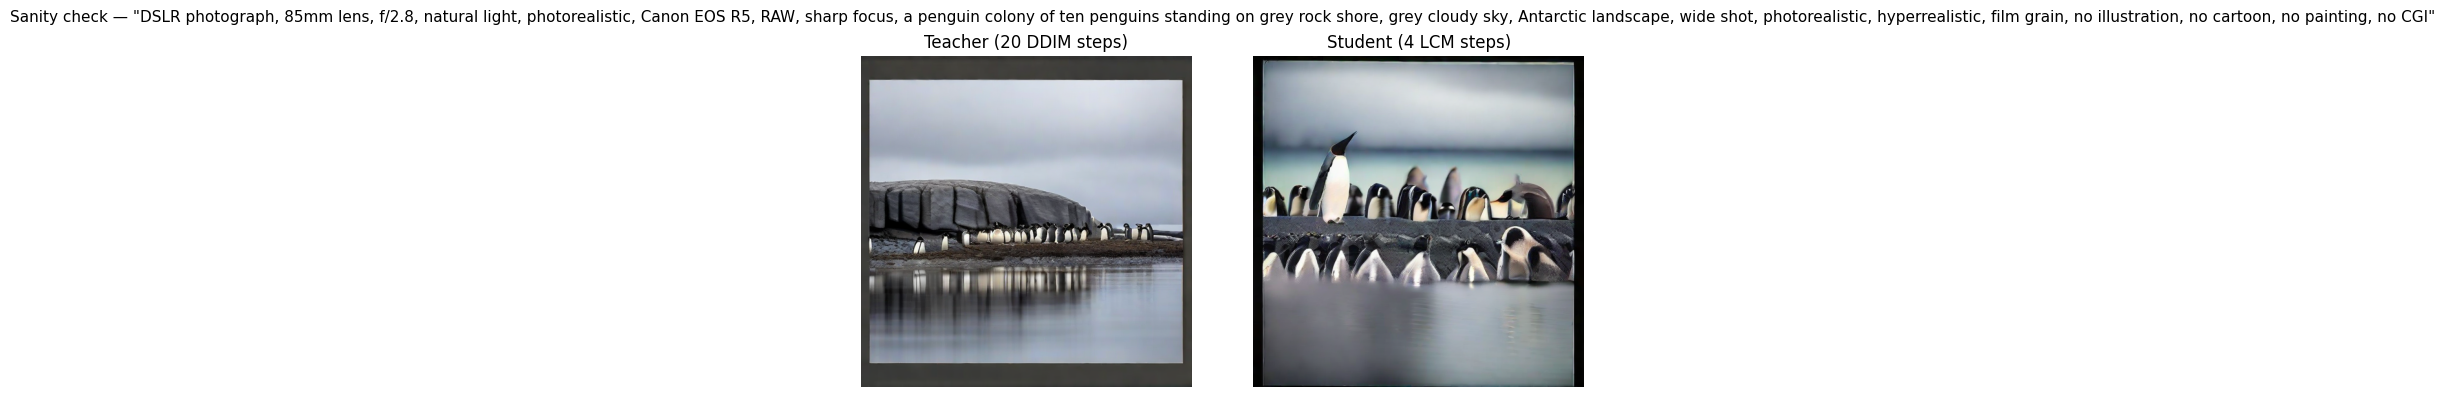

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [9]:
    v[00]: 4.6505
    v[01]: 10.7469
    v[02]: 26.7195
    v[03]: 16.2080
    v[04]: 5.6130
    v[05]: 9.7399
    v[06]: 12.1438
    v[07]: 15.1347
    v[08]: 42.0384
    v[09]: 7.2095
  ε_s=102.2829 | ε_g(mean)=15.0204 | ε_g(median)=11.4453 | ±10.8616 | ‖f_φ‖=96.0264 | ‖∂_x[vᵀf_φ]‖=0.3527

[10/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a white-tailed deer eating grass in a misty pine forest, early morning, soft diffused light, side profile, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


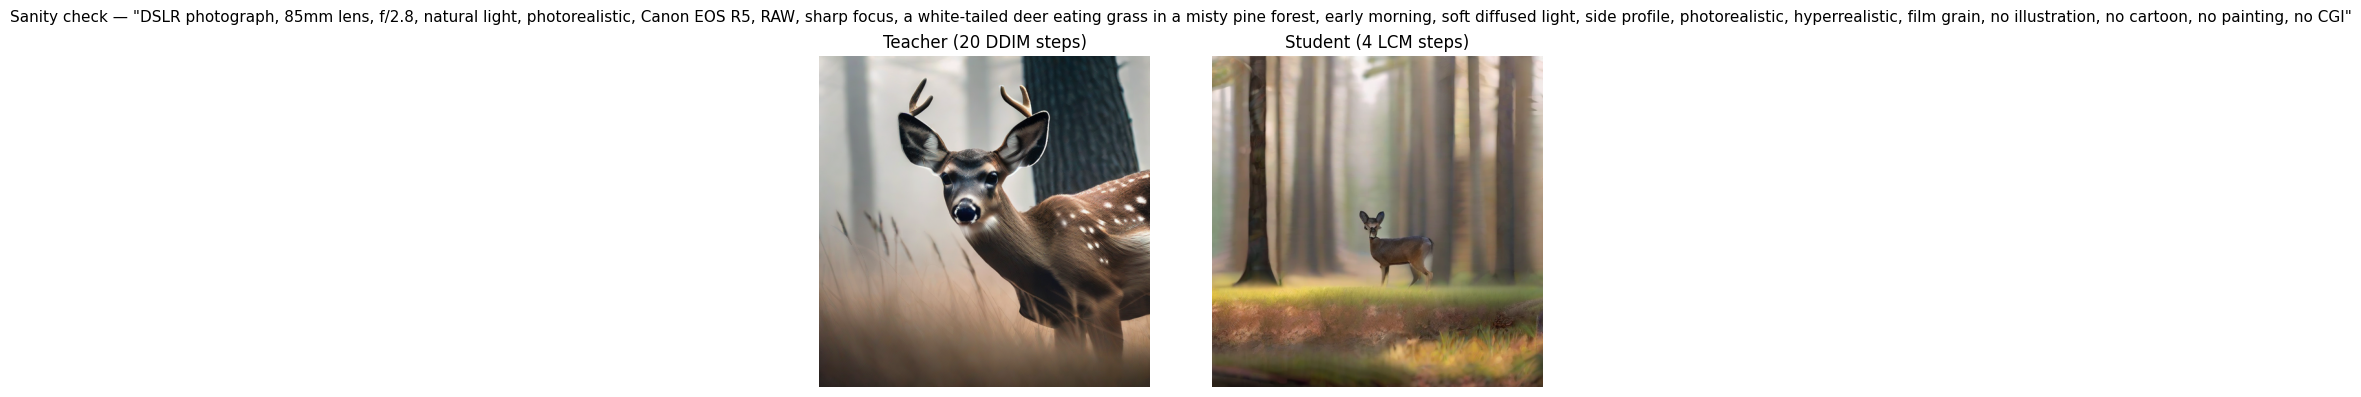

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', no cgi']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', no cgi']


  Individual ‖g_t - g_s‖ norms for prompt [10]:
    v[00]: 10386.5771
    v[01]: 5243.5967
    v[02]: 4246.2935
    v[03]: 2571.1670
    v[04]: 4938.3018
    v[05]: 9901.9424
    v[06]: 718.7440
    v[07]: 9346.1182
    v[08]: 11131.0078
    v[09]: 4834.8350
  ε_s=109.7087 | ε_g(mean)=6331.8583 | ε_g(median)=5090.9492 | ±3415.7088 | ‖f_φ‖=84.7757 | ‖∂_x[vᵀf_φ]‖=0.3084

[11/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a red Ferrari 458 parked on a winding grey asphalt mountain road, rocky cliff on the left, clear blue sky, noon light, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


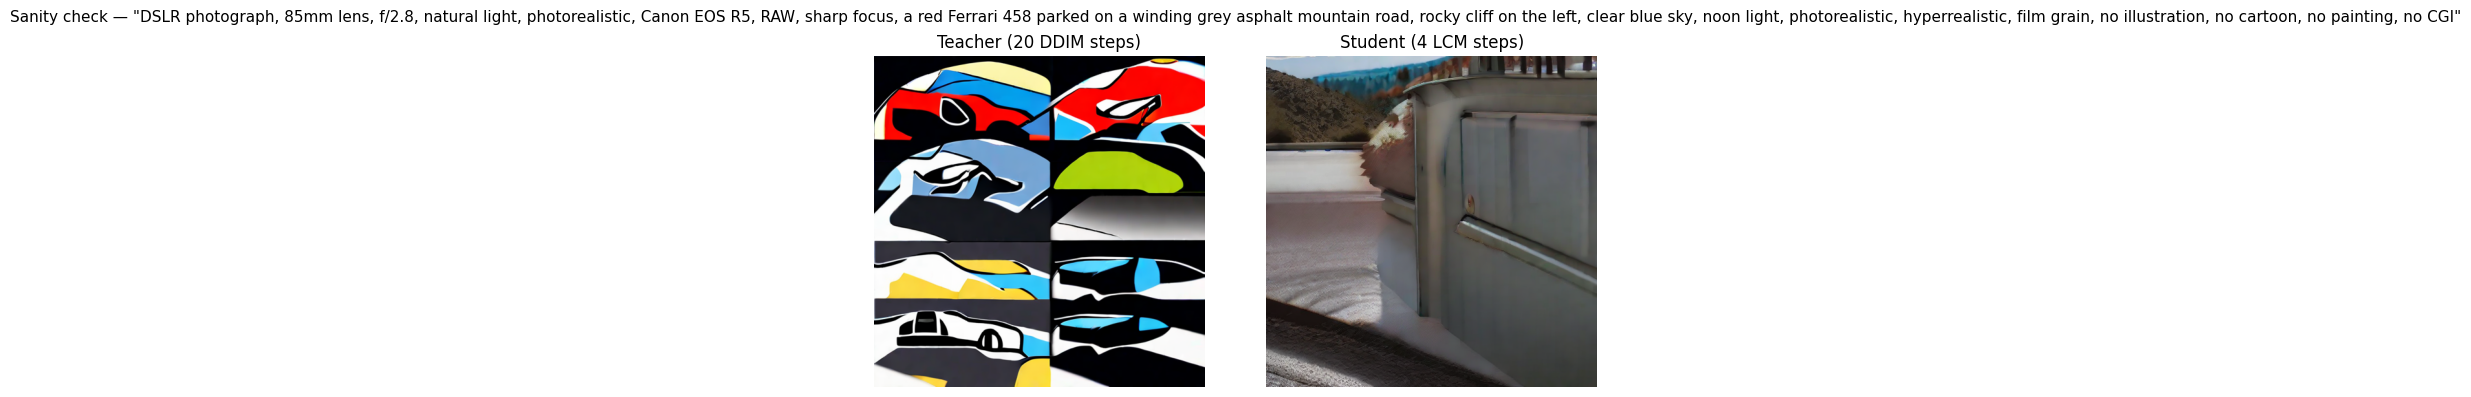

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  Individual ‖g_t - g_s‖ norms for prompt [11]:
    v[00]: 1402.3911
    v[01]: 2548.0234
    v[02]: 1116.4052
    v[03]: 2952.8411
    v[04]: 1316.9384
    v[05]: 1947.3555
    v[06]: 748.6574
    v[07]: 1213.8094
    v[08]: 1511.5980
    v[09]: 5725.5923
  ε_s=174.9205 | ε_g(mean)=2048.3612 | ε_g(median)=1456.9946 | ±1381.8320 | ‖f_φ‖=87.1311 | ‖∂_x[vᵀf_φ]‖=0.8255

[12/50] "DSLR photograph, 85mm lens, f/2.8, natural light, photorealistic, Canon EOS R5, RAW, sharp focus, a black steam locomotive moving right through dense golden autumn forest, grey smoke from chimney, side view, photorealistic, hyperrealistic, film grain, no illustration, no cartoon, no painting, no CGI"


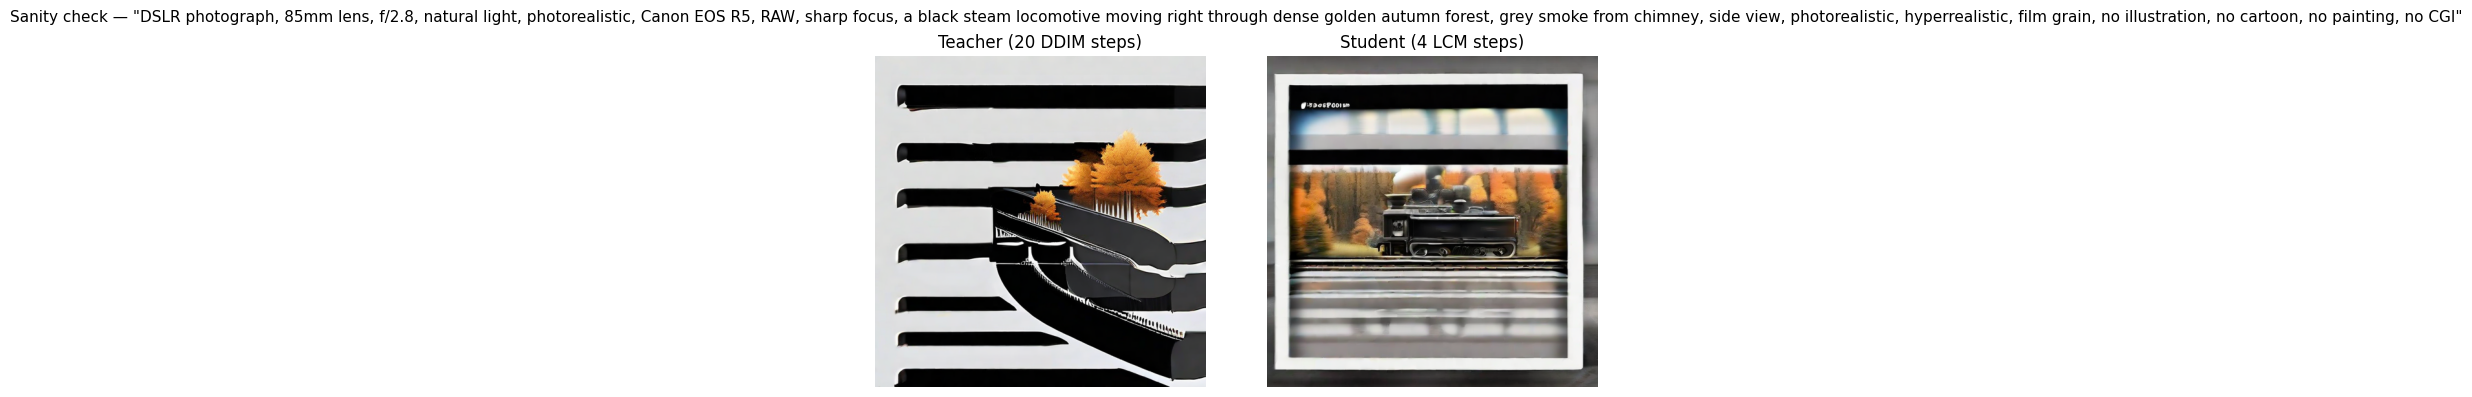

In [ ]:
# Schedulers
sched = DDIMScheduler.from_config(teacher_pipe.scheduler.config)
sched.set_timesteps(N_TEACHER_SAMPLE_STEPS, device=device)

lcm_sched = LCMScheduler.from_config(student_pipe.scheduler.config)
lcm_sched.set_timesteps(N_STUDENT_SAMPLE_STEPS, device=device)

# Make sure all models are in eval mode
teacher_pipe.unet.eval()
teacher_pipe.vae.eval()
student_unet.eval()

def decode(latent):
    with torch.no_grad():
        teacher_pipe.vae.to(torch.float32)
        img = teacher_pipe.vae.decode(
            latent.float() / teacher_pipe.vae.config.scaling_factor
        ).sample
        teacher_pipe.vae.to(dtype)
    img = (img / 2 + 0.5).clamp(0, 1)
    img = img.squeeze(0).permute(1, 2, 0).float().detach().cpu().numpy()
    return (img * 255).astype("uint8")

records = []

print("ε_s / ε_g experiment")
print(f"  Teacher: {N_TEACHER_SAMPLE_STEPS} DDIM steps, z_T → z_0, guidance={GUIDANCE_W_TEACHER}")
print(f"  Student: {N_STUDENT_SAMPLE_STEPS} LCM  steps, z_T → z_0, guidance={GUIDANCE_W_STUDENT}")
print(f"  VJP directions: {N_RANDOM_V}")

for i, prompt in enumerate(PROMPTS):

    print(f"\n[{i+1}/{len(PROMPTS)}] \"{prompt}\"")

    lcm_sched = LCMScheduler.from_config(student_pipe.scheduler.config)
    lcm_sched.set_timesteps(N_STUDENT_SAMPLE_STEPS, device=device)

    sched = DDIMScheduler.from_config(teacher_pipe.scheduler.config)   # ← ADD THIS
    sched.set_timesteps(N_TEACHER_SAMPLE_STEPS, device=device)

    # ── encode current prompt (not always PROMPTS[0]) ─────────────────
    pe, pooled, ne, n_pooled = encode_prompt(teacher_pipe, prompt)

    # ── shared noise ──────────────────────────────────────────────────
    torch.manual_seed(SEED + i)
    z_T = torch.randn(1, 4, HEIGHT // 8, WIDTH // 8, dtype=dtype, device=device)

    # ── closures ──────────────────────────────────────────────────────
    def f_teacher(x): return teacher_full(sched, z_T, 0, x, pooled, ne, n_pooled)
    def f_student(x): return student_n_steps(lcm_sched, z_T, 0, x, pooled, N_STUDENT_SAMPLE_STEPS)

    # ── output gap  ε_s = ‖f★(x) − fφ(x)‖ ───────────────────────────
    with torch.no_grad():
        out_t = f_teacher(pe)
        out_s = f_student(pe)

    # ── decode and display ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(decode(out_t))
    axes[0].set_title(f"Teacher ({N_TEACHER_SAMPLE_STEPS} DDIM steps)")
    axes[0].axis("off")
    axes[1].imshow(decode(out_s))
    axes[1].set_title(f"Student ({N_STUDENT_SAMPLE_STEPS} LCM steps)")
    axes[1].axis("off")
    plt.suptitle(f'Sanity check — "{prompt}"', fontsize=11)
    plt.tight_layout()
    plt.show()

    eps_s      = (out_t - out_s).float().norm().item()
    f_phi_norm = out_s.float().norm().item()
    out_shape  = out_t.shape
    del out_t, out_s; torch.cuda.empty_cache()
    # continue
    # if i==2:
      # break
    # continue
    # ── Jacobian gap  ε_g via random VJPs ────────────────────────────
    vjp_norms   = []
    J_phi_norms = []
    for kk in range(N_RANDOM_V):
        torch.manual_seed(4000 + 100 * i + kk)
        v = torch.randn(*out_shape, dtype=dtype, device=device)
        v = v / v.norm()

        g_t = compute_vjp(f_teacher, pe, v)
        g_s = compute_vjp(f_student, pe, v)
        vjp_norms.append((g_t - g_s).float().norm().item())
        J_phi_norms.append(g_s.float().norm().item())
        del g_t, g_s; torch.cuda.empty_cache()

    eps_g        = float(np.mean(vjp_norms))
    eps_g_median = float(np.median(vjp_norms))
    eps_g_std    = float(np.std(vjp_norms))
    J_phi_mean   = float(np.mean(J_phi_norms))

    print(f"  Individual ‖g_t - g_s‖ norms for prompt [{i+1}]:")
    for kk, val in enumerate(vjp_norms):
        print(f"    v[{kk:02d}]: {val:.4f}")

    records.append(dict(
        prompt_idx=i, prompt=prompt,
        eps_s=eps_s, eps_g=eps_g, eps_g_median=eps_g_median, eps_g_std=eps_g_std,
        f_phi_norm=f_phi_norm, J_phi_mean=J_phi_mean,
    ))
    print(f"  ε_s={eps_s:7.4f} | ε_g(mean)={eps_g:.4f} | ε_g(median)={eps_g_median:.4f} | "
          f"±{eps_g_std:.4f} | ‖f_φ‖={f_phi_norm:.4f} | ‖∂_x[vᵀf_φ]‖={J_phi_mean:.4f}")

df = pd.DataFrame(records)
print("\nDone.")

## §6 — Results

### Summary table


In [ ]:
y_bar = float(np.sqrt(np.mean(df["f_phi_norm"].values ** 2)))
J_bar = float(np.sqrt(np.mean(df["J_phi_mean"].values ** 2)))

df["hat_r_s"] = df["eps_s"] / y_bar
df["hat_r_g"] = df["eps_g"] / J_bar
df["hat_r_g_median"] = df["eps_g_median"] / J_bar

print(f"{'ε_s':>14} | {'ε_g (mean)':>20} | {'ε_g (median)':>14} | {'r̂_s':>10} | {'r̂_g(mean)':>12} | {'r̂_g(median)':>13}")
print("-" * 110)
print(
    f"{df['eps_s'].mean():>6.4f} ± {df['eps_s'].std():>5.4f} | "
    f"{df['eps_g'].mean():>6.4f} ± {df['eps_g_std'].mean():>5.4f} | "
    f"{df['eps_g_median'].mean():>14.4f} | "
    f"{df['hat_r_s'].mean():>10.4f} | "
    f"{df['hat_r_g'].mean():>12.4f} | "
    f"{df['hat_r_g_median'].mean():>13.4f}"
)
print("=" * 110)
print(df[["prompt", "eps_s", "eps_g", "eps_g_median", "eps_g_std", "hat_r_s", "hat_r_g", "hat_r_g_median"]].to_string(index=False))


print("=" * 90)



           ε_s |           ε_g (mean) |   ε_g (median) |       r̂_s |   r̂_g(mean) |  r̂_g(median)
--------------------------------------------------------------------------------------------------------------
168.5746 ± 17.7155 | 2445.6757 ± 1398.0782 |      2251.9581 |     1.5235 |    4186.6583 |     3855.0406
                                             prompt      eps_s        eps_g  eps_g_median    eps_g_std  hat_r_s      hat_r_g  hat_r_g_median
         a golden retriever playing in a sunny park 119.865051   151.033298    143.414440    70.997343 1.083256   258.548100      245.505670
                a red sports car on a mountain road 154.023102    45.672810     32.836868    36.394861 1.391953    78.185528       56.212173
         a bowl of colorful fruit on a wooden table 148.355164   174.072501    136.915085   137.237924 1.340730   297.988026      234.379673
                    a snowy mountain peak at sunset 194.658371   106.851696     89.063843    41.778349 1.759186   182.9153

Valid prompts after NaN removal: 48 / 50


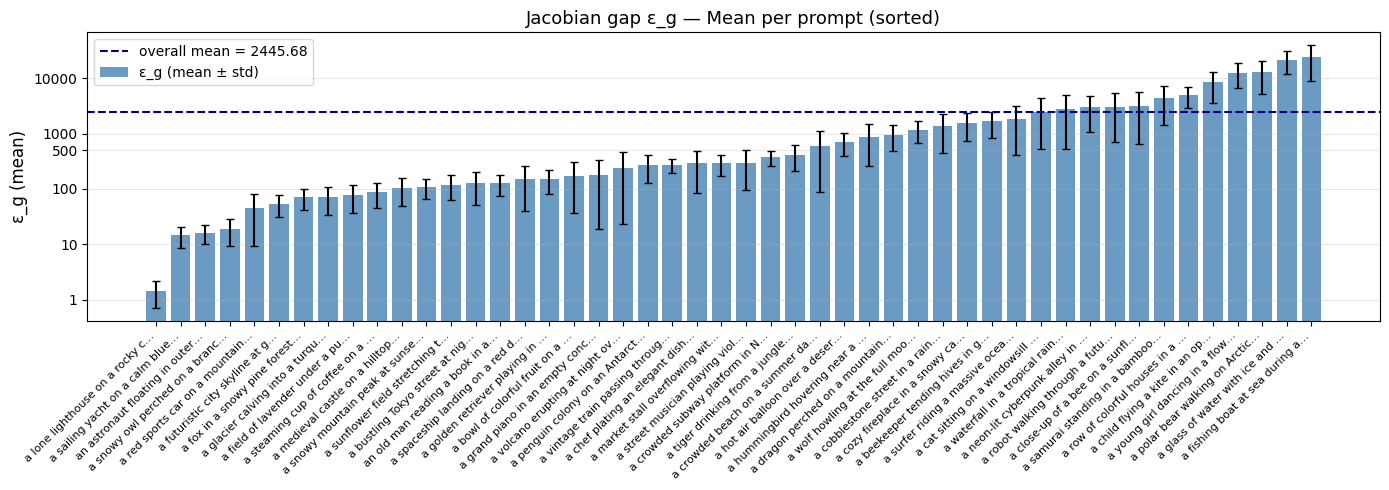

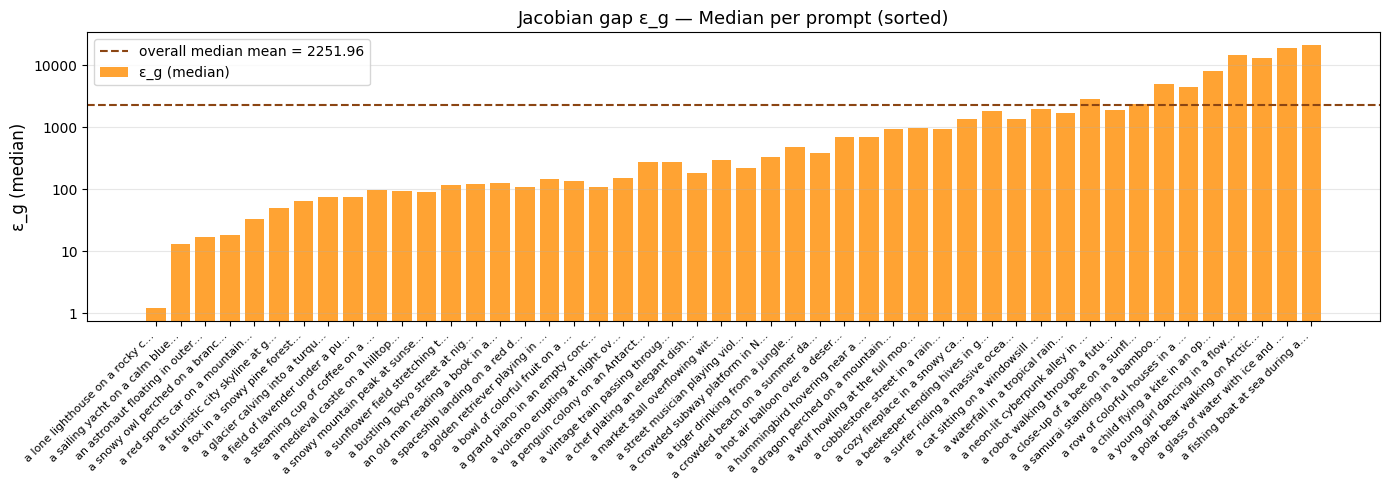

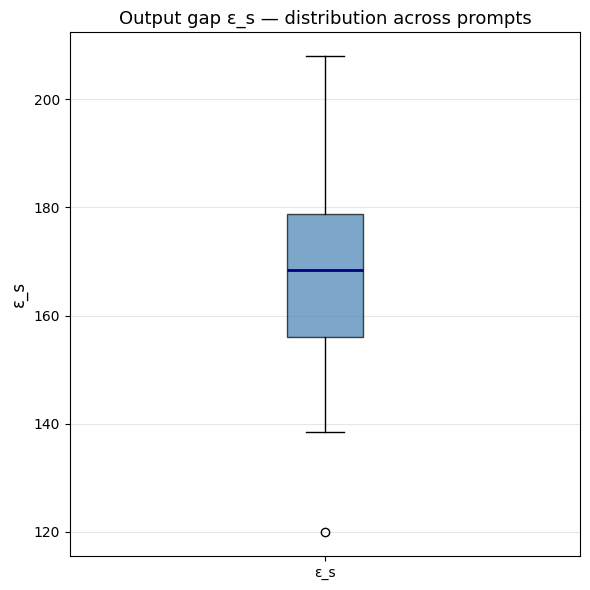

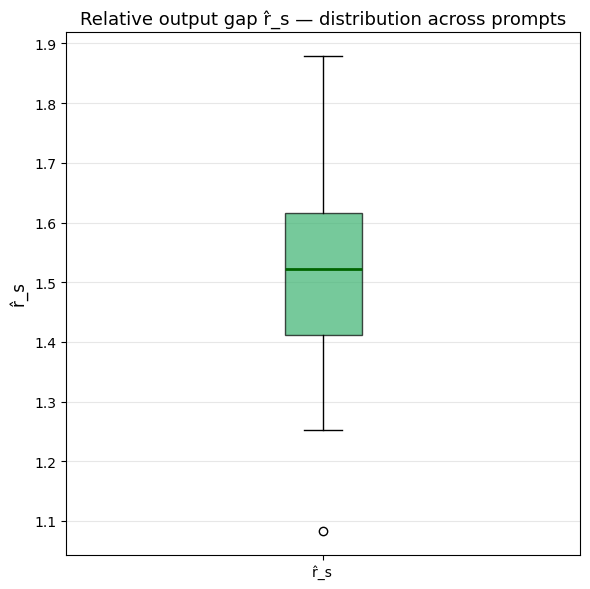

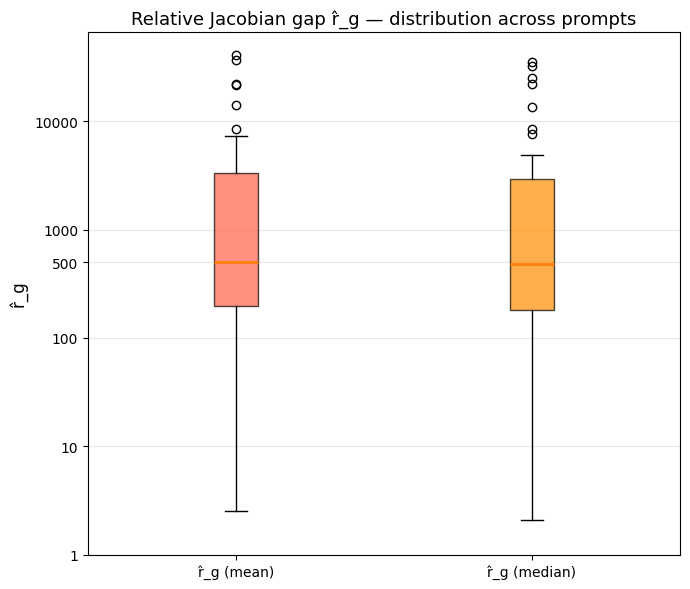

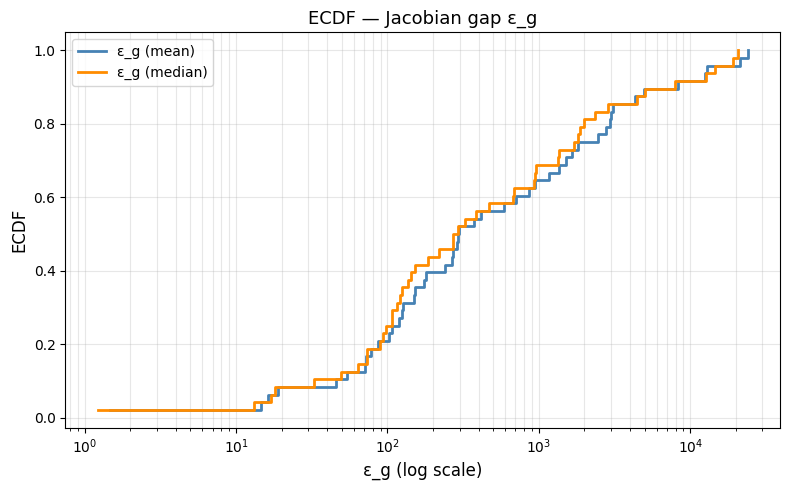

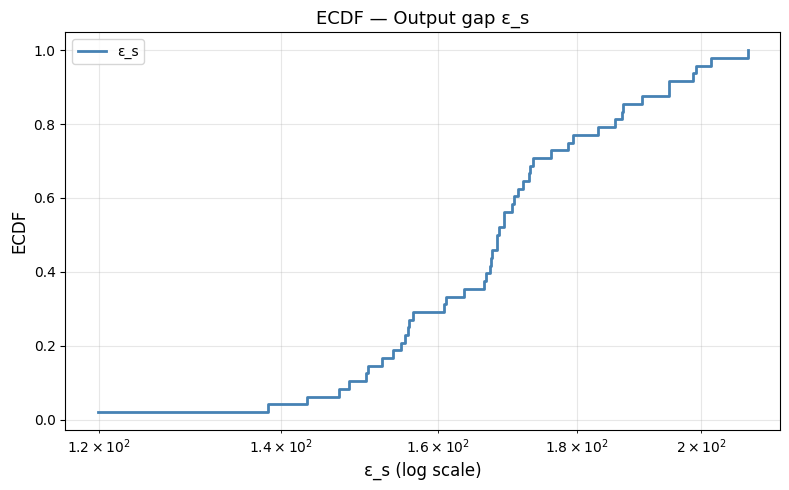

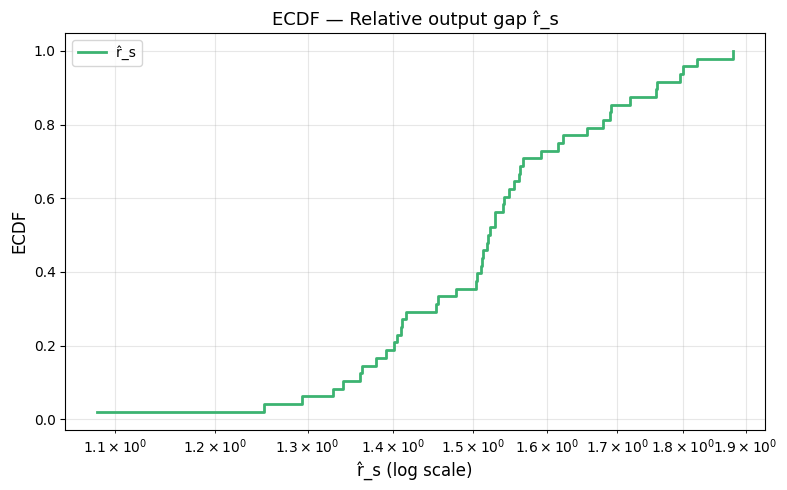

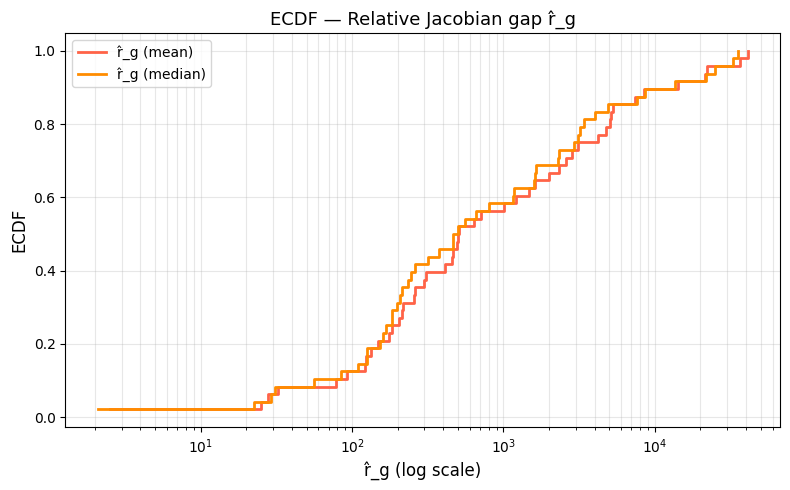

In [ ]:
# ── convert to plain numpy to avoid CUDA tensor issues ───────────────
x = np.arange(len(df))
short_prompts = [p[:30] + "…" for p in df["prompt"]]
eps_g        = df["eps_g"].values.astype(float)
eps_g_std    = df["eps_g_std"].values.astype(float)
eps_g_median = df["eps_g_median"].values.astype(float)
eps_s        = df["eps_s"].values.astype(float)
hat_r_s      = df["hat_r_s"].values.astype(float)
hat_r_g      = df["hat_r_g"].values.astype(float)
hat_r_g_med  = df["hat_r_g_median"].values.astype(float)

# ── remove NaN entries (same mask applied to all arrays) ─────────────
valid = (
    np.isfinite(eps_g) & np.isfinite(eps_g_std) & np.isfinite(eps_g_median) &
    np.isfinite(eps_s) & np.isfinite(hat_r_s) & np.isfinite(hat_r_g) &
    np.isfinite(hat_r_g_med)
)
eps_g        = eps_g[valid]
eps_g_std    = eps_g_std[valid]
eps_g_median = eps_g_median[valid]
eps_s        = eps_s[valid]
hat_r_s      = hat_r_s[valid]
hat_r_g      = hat_r_g[valid]
hat_r_g_med  = hat_r_g_med[valid]
short_prompts = [p for p, v in zip(short_prompts, valid) if v]
print(f"Valid prompts after NaN removal: {valid.sum()} / {len(valid)}")

# ── sort by eps_g ascending ───────────────────────────────────────────
sort_idx       = np.argsort(eps_g)
eps_g_s        = eps_g[sort_idx]
eps_g_std_s    = eps_g_std[sort_idx]
eps_g_median_s = eps_g_median[sort_idx]
prompts_s      = [short_prompts[i] for i in sort_idx]

x_s            = np.arange(len(eps_g_s))

# ── ε_g mean bar (sorted, log scale) ─────────────────────────────────
fig1, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_s, eps_g_s, yerr=np.minimum(eps_g_std_s, eps_g_s * 0.99), capsize=3,
       color="steelblue", alpha=0.8, label="ε_g (mean ± std)")
ax.axhline(eps_g_s.mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"overall mean = {eps_g_s.mean():.2f}")
ax.set_ylabel("ε_g (mean)", fontsize=12)
ax.set_title("Jacobian gap ε_g — Mean per prompt (sorted)", fontsize=13)
ax.set_xticks(x_s); ax.set_xticklabels(prompts_s, rotation=45, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_yticks([1, 10, 100, 500,1000, 10000])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3, which="major")
plt.tight_layout(); plt.savefig("fig_eps_g_mean.png", dpi=120, bbox_inches="tight"); plt.show()

# ── ε_g median bar (sorted by same index, log scale) ─────────────────
fig2, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_s, eps_g_median_s, color="darkorange", alpha=0.8, label="ε_g (median)")
ax.axhline(eps_g_median_s.mean(), color="saddlebrown", linestyle="--", linewidth=1.5,
           label=f"overall median mean = {eps_g_median_s.mean():.2f}")
ax.set_ylabel("ε_g (median)", fontsize=12)
ax.set_title("Jacobian gap ε_g — Median per prompt (sorted)", fontsize=13)
ax.set_xticks(x_s); ax.set_xticklabels(prompts_s, rotation=45, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_yticks([1, 10, 100, 1000, 10000])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3, which="major")
plt.tight_layout(); plt.savefig("fig_eps_g_median.png", dpi=120, bbox_inches="tight"); plt.show()

# ── ε_s boxplot ───────────────────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(eps_s, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7),
           medianprops=dict(color="navy", linewidth=2))
ax.set_ylabel("ε_s", fontsize=12)
ax.set_title("Output gap ε_s — distribution across prompts", fontsize=13)
ax.set_xticks([1]); ax.set_xticklabels(["ε_s"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig_eps_s_box.png", dpi=120, bbox_inches="tight"); plt.show()

# ── r̂_s boxplot ──────────────────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(hat_r_s, patch_artist=True,
           boxprops=dict(facecolor="mediumseagreen", alpha=0.7),
           medianprops=dict(color="darkgreen", linewidth=2))
ax.set_ylabel("r̂_s", fontsize=12)
ax.set_title("Relative output gap r̂_s — distribution across prompts", fontsize=13)
ax.set_xticks([1]); ax.set_xticklabels(["r̂_s"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig_hat_r_s_box.png", dpi=120, bbox_inches="tight"); plt.show()

# ── r̂_g boxplot ──────────────────────────────────────────────────────
fig5, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot([hat_r_g, hat_r_g_med], patch_artist=True,
                medianprops=dict(linewidth=2))
for patch, color in zip(bp["boxes"], ["tomato", "darkorange"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel("r̂_g", fontsize=12)
ax.set_title("Relative Jacobian gap r̂_g — distribution across prompts", fontsize=13)
ax.set_xticks([1, 2]); ax.set_xticklabels(["r̂_g (mean)", "r̂_g (median)"])
ax.set_yscale("log")
ax.set_yticks([1, 10, 100, 500, 1000, 10000])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.grid(axis="y", alpha=0.3, which="major")
plt.tight_layout(); plt.savefig("fig_hat_r_g_box.png", dpi=120, bbox_inches="tight"); plt.show()


# ══ ECDF versions (log scale) ════════════════════════════════════════

def plot_ecdf(data_dict, title, filename, xlabel):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, arr, color in data_dict:
        sorted_arr = np.sort(arr)
        ecdf_y = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
        ax.step(sorted_arr, ecdf_y, where="post", label=label, color=color, linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel(f"{xlabel} (log scale)", fontsize=12)
    ax.set_ylabel("ECDF", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10); ax.grid(alpha=0.3, which="both")
    plt.tight_layout(); plt.savefig(filename, dpi=120, bbox_inches="tight"); plt.show()

plot_ecdf(
    [("ε_g (mean)", eps_g, "steelblue"), ("ε_g (median)", eps_g_median, "darkorange")],
    "ECDF — Jacobian gap ε_g", "fig_ecdf_eps_g.png", "ε_g"
)
plot_ecdf(
    [("ε_s", eps_s, "steelblue")],
    "ECDF — Output gap ε_s", "fig_ecdf_eps_s.png", "ε_s"
)
plot_ecdf(
    [("r̂_s", hat_r_s, "mediumseagreen")],
    "ECDF — Relative output gap r̂_s", "fig_ecdf_hat_r_s.png", "r̂_s"
)
plot_ecdf(
    [("r̂_g (mean)", hat_r_g, "tomato"), ("r̂_g (median)", hat_r_g_med, "darkorange")],
    "ECDF — Relative Jacobian gap r̂_g", "fig_ecdf_hat_r_g.png", "r̂_g"
)